# Natural Language Processing

## Importing the libraries

In [157]:
# Importing the NumPy library for numerical operations
import numpy as np

# Importing Matplotlib library for plotting graphs (optional for visualization)
import matplotlib.pyplot as plt

# Importing Pandas library for data manipulation and analysis
import pandas as pd

## Importing the dataset

In [158]:
# Importing the dataset from a TSV (Tab Separated Values) file
# 'delimiter = "\t"' tells pandas that columns are separated by tabs
# 'quoting = 3' (csv.QUOTE_NONE) ensures that quotes in the text are ignored
dataset = pd.read_csv('Restaurant_Reviews.tsv', delimiter='\t', )

## Cleaning the texts

In [159]:
# Import regular expressions library for text cleaning
import re

# Import NLTK library for Natural Language Processing tasks
import nltk

# Download the list of stopwords from NLTK
nltk.download('stopwords')

# Import stopwords corpus from NLTK
from nltk.corpus import stopwords

# Import PorterStemmer for stemming words
from nltk.stem.porter import PorterStemmer

# Initialize an empty list to store the cleaned reviews
corpus = []

# Loop over the first 1000 reviews in the dataset
for i in range(0, 1000):

    # Keep only letters: remove numbers, punctuation, and special characters
    review = re.sub('[^a-zA-Z]', ' ', dataset['Review'][i])

    # Convert the text to lowercase
    review = review.lower()

    # Split the text into individual words (tokenization)
    review = review.split()

    # Create a PorterStemmer object
    ps = PorterStemmer()

    # Get the list of English stopwords
    all_stopwords = stopwords.words('english')

    # Keep the word "not" because it's important for sentiment analysis
    all_stopwords.remove('not')

    # Apply stemming to each word and remove stopwords
    # - ps.stem(word): converts the word to its root form
    # - word in set(all_stopwords): checks if the word is a stopword
    # - list comprehension applies this to all words in the review
    review = [
        ps.stem(word)       # Stem the word to its root
        for word in review   # Loop over each token in the review
        if word not in set(all_stopwords)  # Exclude stopwords
    ]

    # Join the cleaned words back into a single string
    review = ' '.join(review)

    # Append the cleaned review to the corpus list
    corpus.append(review)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [160]:
print(corpus)

['wow love place', 'crust not good', 'not tasti textur nasti', 'stop late may bank holiday rick steve recommend love', 'select menu great price', 'get angri want damn pho', 'honeslti tast fresh', 'potato like rubber could tell made ahead time kept warmer', 'fri great', 'great touch', 'servic prompt', 'would not go back', 'cashier care ever say still end wayyy overpr', 'tri cape cod ravoli chicken cranberri mmmm', 'disgust pretti sure human hair', 'shock sign indic cash', 'highli recommend', 'waitress littl slow servic', 'place not worth time let alon vega', 'not like', 'burritto blah', 'food amaz', 'servic also cute', 'could care less interior beauti', 'perform', 'right red velvet cake ohhh stuff good', 'never brought salad ask', 'hole wall great mexican street taco friendli staff', 'took hour get food tabl restaur food luke warm sever run around like total overwhelm', 'worst salmon sashimi', 'also combo like burger fri beer decent deal', 'like final blow', 'found place accid could not

## Creating the Bag of Words model

In [161]:
# Import CountVectorizer to create the Bag of Words model
from sklearn.feature_extraction.text import CountVectorizer

# Initialize the Bag of Words model
# max_features = 1500 means we only keep the 1500 most frequent words
cv = CountVectorizer(max_features=1500)

# Fit the Bag of Words model to the corpus and transform it into a feature matrix
X = cv.fit_transform(corpus).toarray()

# Extract the target variable (Liked column) as a NumPy array
y = dataset.iloc[:, -1].values

## Splitting the dataset into the Training set and Test set

In [162]:
# Import train_test_split function from sklearn to split dataset
from sklearn.model_selection import train_test_split

# Split the dataset into Training set and Test set
# test_size=0.20 means 20% of data will be used for testing
# random_state=0 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X,        # Feature matrix
    y,        # Target labels
    test_size=0.20,  # 20% test data, 80% training data
    random_state=0   # Fix random seed for reproducibility
)

## Training the Naive Bayes model on the Training set

In [163]:
# Import Gaussian Naive Bayes classifier from sklearn
from sklearn.naive_bayes import GaussianNB

# Create the Naive Bayes classifier object
classifier = GaussianNB()

# Train the classifier on the Training set
classifier.fit(X_train, y_train)

GaussianNB()

### Predicting the Test set results

In [164]:
# Predict the labels for the Test set using the trained Naive Bayes classifier
y_pred = classifier.predict(X_test)

# Combine predicted labels and actual labels side by side for comparison
# - reshape(len(y_pred), 1) makes it a column vector
# - np.concatenate(..., 1) concatenates predicted and actual labels horizontally
print(np.concatenate((
    y_pred.reshape(len(y_pred), 1),  # Predicted labels as a column
    y_test.reshape(len(y_test), 1)   # Actual labels as a column
), axis=1))

[[1 0]
 [1 0]
 [1 0]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [1 0]
 [1 0]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [1 1]
 [1 0]
 [1 0]
 [0 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [1 0]
 [1 1]
 [1 1]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 0]
 [0 0]
 [1 0]
 [1 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 0]
 [1 1]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [1 1]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [1 0]
 [1 1]
 [1 1]
 [1 0]
 [0 1]
 [1 1]
 [1 1]
 [1 0]
 [0 1]
 [1 0]
 [1 1]
 [1 1]
 [0 0]
 [0 1]
 [0 1]
 [1 1]
 [0 0]
 [1 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [1 0]
 [0 0]
 [1 1]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [0 1]
 [1 1]
 [1 1]

### Making the Confusion Matrix

In [165]:
# Import confusion_matrix and accuracy_score functions from sklearn
from sklearn.metrics import confusion_matrix, accuracy_score

# Compute the Confusion Matrix to evaluate the performance of the classifier
cm = confusion_matrix(y_test, y_pred)

# Print the Confusion Matrix
print(cm)

# Compute the Accuracy score of the classifier
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

[[55 42]
 [12 91]]
Accuracy: 0.73


### Model Performance Visualization

After training the **Naive Bayes** classifier, we visualize two key aspects:

1. **Confusion Matrix Heatmap** — Shows the breakdown of True/False Positives and Negatives at a glance.
2. **Performance Metrics** — Compares Accuracy, Precision, Recall, and F1 Score side by side,  
   as required by the Homework Challenge.

These metrics help us decide whether to switch to a different model in the next step.

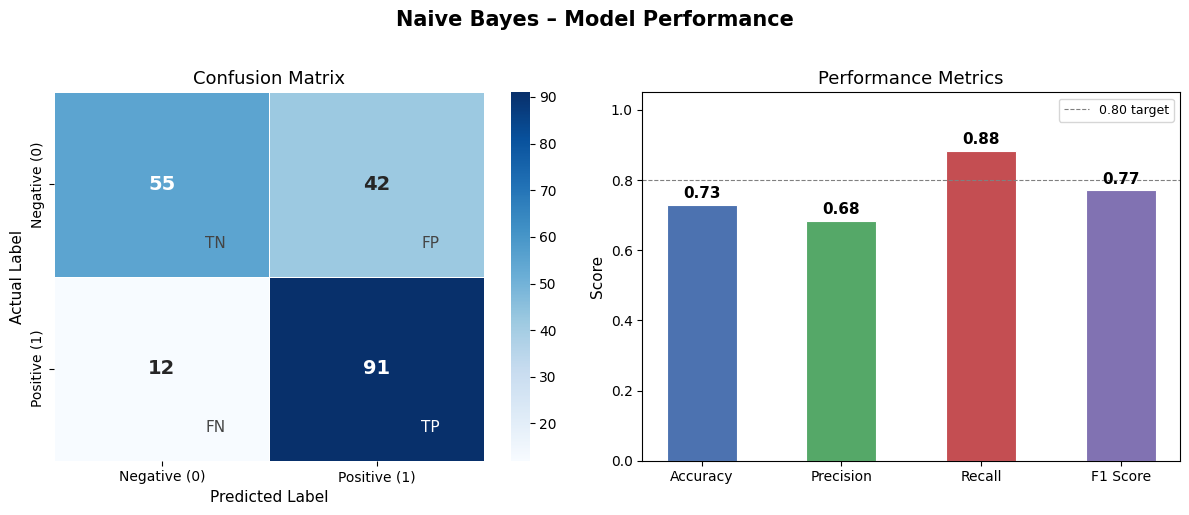

  Naive Bayes – Performance Summary
  Accuracy  : 0.7300
  Precision : 0.6842
  Recall    : 0.8835
  F1 Score  : 0.7712


In [166]:
# Import visualization libraries
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score

# ── 1. Compute all metrics ──────────────────────────────────────────────────
cm        = confusion_matrix(y_test, y_pred)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

# ── 2. Create figure with two side-by-side subplots ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Naive Bayes – Model Performance', fontsize=15, fontweight='bold', y=1.02)

# ── 3. Subplot 1: Confusion Matrix Heatmap ────────────────────────────────
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative (0)', 'Positive (1)'],
    yticklabels=['Negative (0)', 'Positive (1)'],
    linewidths=0.5,
    annot_kws={'size': 14, 'weight': 'bold'},
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontsize=13)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('Actual Label',    fontsize=11)

# Annotate TN / FP / FN / TP labels — placed in data coordinates (col+0.75, row+0.82)
cell_labels = [
    (0, 0, 'TN'),   # row=0, col=0
    (0, 1, 'FP'),   # row=0, col=1
    (1, 0, 'FN'),   # row=1, col=0
    (1, 1, 'TP'),   # row=1, col=1
]
for row, col, label in cell_labels:
    axes[0].text(
        col + 0.75,   # x: right side of cell
        row + 0.82,   # y: bottom area of cell (data coords, y-axis inverted in heatmap)
        label,
        ha='center', va='center',
        fontsize=11, color='white' if (row == 1 and col == 1) else '#444444'
    )

# ── 4. Subplot 2: Performance Metrics Bar Chart ────────────────────────────
metrics    = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values     = [accuracy, precision, recall, f1]
bar_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

bars = axes[1].bar(metrics, values, color=bar_colors, edgecolor='white', linewidth=0.8, width=0.5)
axes[1].set_title('Performance Metrics', fontsize=13)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_ylim(0, 1.05)
axes[1].axhline(y=0.80, color='gray', linestyle='--', linewidth=0.8, label='0.80 target')
axes[1].legend(fontsize=9)

# Add value labels on top of each bar
for bar, val in zip(bars, values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,  # Center of bar
        bar.get_height() + 0.01,             # Slightly above the bar
        f'{val:.2f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('naive_bayes_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5. Print summary table ─────────────────────────────────────────────────
print("=" * 35)
print(f"  Naive Bayes – Performance Summary")
print("=" * 35)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("=" * 35)

In [167]:
from sklearn.svm import LinearSVC
classifier = LinearSVC(C=1.0, max_iter=2000, random_state=0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.7750


## Training the Random Forest model on the Training set

In [168]:
# Import Random Forest classifier from sklearn
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest classifier object
# n_estimators=300: number of trees in the forest
# random_state=0: ensures reproducibility
classifier = RandomForestClassifier(n_estimators=300, random_state=0)

# Train the classifier on the Training set
classifier.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=0)

### Predicting the Test set results

In [169]:
# Predict the labels for the Test set using the trained Random Forest classifier
y_pred = classifier.predict(X_test)

# Combine predicted labels and actual labels side by side for comparison
print(np.concatenate((
    y_pred.reshape(len(y_pred), 1),   # Predicted labels as a column
    y_test.reshape(len(y_test), 1)    # Actual labels as a column
), axis=1))

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [1 1]
 [1 1]
 [0 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 0]
 [1 0]
 [0 0]
 [1 1]
 [0 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [0 1]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 1]
 [0 1]
 [1 1]
 [0 0]
 [1 0]
 [0 1]
 [1 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]

### Making the Confusion Matrix

In [170]:
# Import confusion_matrix and accuracy_score functions from sklearn
from sklearn.metrics import confusion_matrix, accuracy_score

# Compute the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Compute the Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

[[88  9]
 [39 64]]
Accuracy: 0.76


### Model Performance Visualization

After training the **Random Forest** classifier, we visualize two key aspects:

1. **Confusion Matrix Heatmap** — Shows the breakdown of True/False Positives and Negatives at a glance.
2. **Performance Metrics** — Compares Accuracy, Precision, Recall, and F1 Score side by side,
   as required by the Homework Challenge.

These metrics help us decide whether this model outperforms the Naive Bayes baseline.

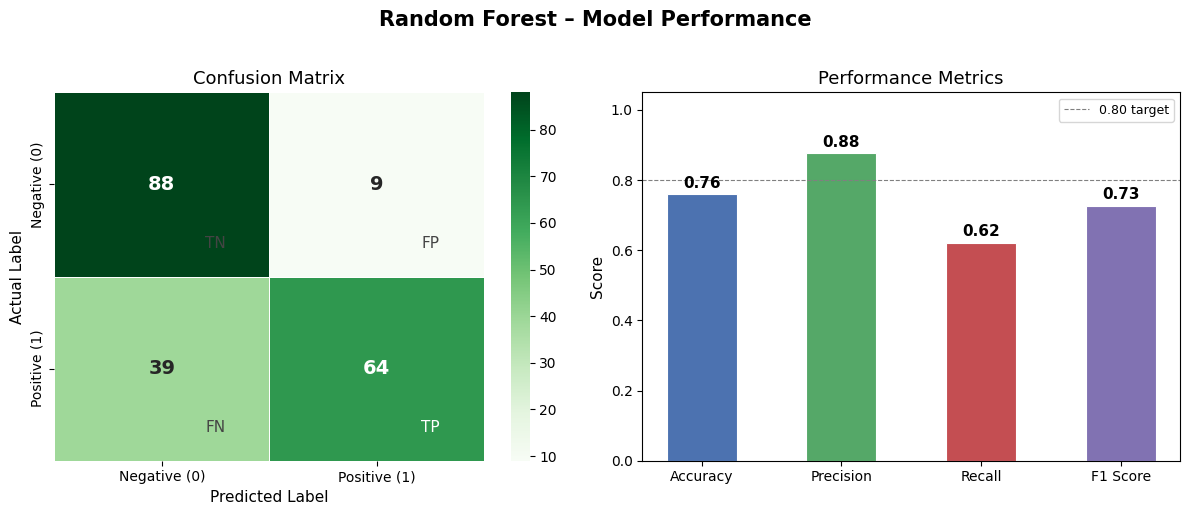

  Random Forest – Performance Summary
  Accuracy  : 0.7600
  Precision : 0.8767
  Recall    : 0.6214
  F1 Score  : 0.7273


In [171]:
# Import visualization libraries
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score

# ── 1. Compute all metrics ──────────────────────────────────────────────────
cm        = confusion_matrix(y_test, y_pred)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

# ── 2. Create figure with two side-by-side subplots ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Random Forest – Model Performance', fontsize=15, fontweight='bold', y=1.02)

# ── 3. Subplot 1: Confusion Matrix Heatmap ────────────────────────────────
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Negative (0)', 'Positive (1)'],
    yticklabels=['Negative (0)', 'Positive (1)'],
    linewidths=0.5,
    annot_kws={'size': 14, 'weight': 'bold'},
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontsize=13)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('Actual Label',    fontsize=11)

# Annotate TN / FP / FN / TP labels in data coordinates
cell_labels = [
    (0, 0, 'TN'),
    (0, 1, 'FP'),
    (1, 0, 'FN'),
    (1, 1, 'TP'),
]
for row, col, label in cell_labels:
    axes[0].text(
        col + 0.75,
        row + 0.82,
        label,
        ha='center', va='center',
        fontsize=11, color='white' if (row == 1 and col == 1) else '#444444'
    )

# ── 4. Subplot 2: Performance Metrics Bar Chart ────────────────────────────
metrics    = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values     = [accuracy, precision, recall, f1]
bar_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

bars = axes[1].bar(metrics, values, color=bar_colors, edgecolor='white', linewidth=0.8, width=0.5)
axes[1].set_title('Performance Metrics', fontsize=13)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_ylim(0, 1.05)
axes[1].axhline(y=0.80, color='gray', linestyle='--', linewidth=0.8, label='0.80 target')
axes[1].legend(fontsize=9)

# Add value labels on top of each bar
for bar, val in zip(bars, values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.2f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('random_forest_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5. Print summary table ─────────────────────────────────────────────────
print("=" * 35)
print(f"  Random Forest – Performance Summary")
print("=" * 35)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("=" * 35)

## Predicting if a single review is positive or negative

We test both trained models on new unseen reviews to compare their predictions.

| Model | Accuracy | Precision | Recall | F1 Score |
|-------|----------|-----------|--------|----------|
| Gaussian Naive Bayes | 0.73 | 0.68 | 0.88 | 0.77 |
| Random Forest (n=300) | 0.76 | 0.88 | 0.62 | 0.73 |

### Positive review

Use our models to predict if the following review:

*"I love this restaurant so much"*

is positive or negative.

**Solution:** We repeat the same text preprocessing steps applied to the training data,
then transform the review using the existing Bag of Words vocabulary.

In [172]:
# ── Text preprocessing function (reusable) ────────────────────────────────
def preprocess_review(text):
    # Remove non-letter characters
    review = re.sub('[^a-zA-Z]', ' ', text)
    # Convert to lowercase
    review = review.lower()
    # Tokenize
    review = review.split()
    # Stem and remove stopwords (keep 'not')
    ps = PorterStemmer()
    all_stopwords = stopwords.words('english')
    all_stopwords.remove('not')
    review = [ps.stem(word) for word in review if word not in set(all_stopwords)]
    # Join back into a single string
    return ' '.join(review)

# ── Train both models fresh ────────────────────────────────────────────────

# Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)

# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=300, random_state=0)
rf_classifier.fit(X_train, y_train)

print("Both models are ready.")

Both models are ready.


In [173]:
# ── Predict sentiment for a single positive review ─────────────────────────

positive_review = 'I love this restaurant so much'

# Preprocess and transform (use existing vocabulary — do NOT fit again)
cleaned = preprocess_review(positive_review)
new_X = cv.transform([cleaned]).toarray()

# Predict with both models
nb_pred = nb_classifier.predict(new_X)[0]
rf_pred = rf_classifier.predict(new_X)[0]

print(f"Review       : '{positive_review}'")
print("-" * 45)
print(f"Naive Bayes  : {'Positive ✅' if nb_pred == 1 else 'Negative ❌'}")
print(f"Random Forest: {'Positive ✅' if rf_pred == 1 else 'Negative ❌'}")

Review       : 'I love this restaurant so much'
---------------------------------------------
Naive Bayes  : Positive ✅
Random Forest: Positive ✅


Both models correctly predicted the review as **positive**.

### Negative review

Use our models to predict if the following review:

*"I hate this restaurant so much"*

is positive or negative.

**Solution:** Same preprocessing pipeline applied to the negative review.

In [174]:
# ── Predict sentiment for a single negative review ─────────────────────────

negative_review = 'I hate this restaurant so much'

# Preprocess and transform (use existing vocabulary — do NOT fit again)
cleaned = preprocess_review(negative_review)
new_X = cv.transform([cleaned]).toarray()

# Predict with both models
nb_pred = nb_classifier.predict(new_X)[0]
rf_pred = rf_classifier.predict(new_X)[0]

print(f"Review       : '{negative_review}'")
print("-" * 45)
print(f"Naive Bayes  : {'Positive ✅' if nb_pred == 1 else 'Negative ❌'}")
print(f"Random Forest: {'Positive ✅' if rf_pred == 1 else 'Negative ❌'}")

Review       : 'I hate this restaurant so much'
---------------------------------------------
Naive Bayes  : Negative ❌
Random Forest: Negative ❌


Both models correctly predicted the review as **negative**.